In [1]:
import numpy as np
import trimesh
from pathlib import Path
import gsd.hoomd

In [ ]:
from photontracer import Simulation, Material, OutputType, MeshGeometry, InstanceGeometry, LengthUnit, MaterialType, IsotropicRayGenerator

In [3]:
def read_particle_meshes(particles_files):
    return [trimesh.load_mesh(file) for file in particles_files]


def load_transforms_from_gsd(filename, apply_scale=False):
    frames = gsd.hoomd.open(filename, 'r')
    assert len(frames) > 0, "No frames found in the GSD file."
    frame = frames[-1]

    print(f"Load file: {filename}")

    particles = frame.particles  # type: ignore
    positions_mm = particles.position
    orientations = particles.orientation
    particle_ids = particles.typeid

    box = frame.configuration.box  # type: ignore
    bx, by, bz = box[0], box[1], box[2]

    # calculate the 4x4 transformation matrix from the rotation vectors
    transformation_matrix = trimesh.transformations.quaternion_matrix(
        orientations)
    if apply_scale:
        # scale the rotation matrix by the particle scales
        scales_mm = np.array(
            [float(type[:-2]) / 2 for type in particles.types])
        transformation_matrix[:, :3,
                              :3] *= scales_mm[particle_ids, np.newaxis, np.newaxis]

    # add the translation to the transformation matrix and remove the last row
    transformation_matrix[:, :3, 3] = positions_mm

    transformation_matrix = transformation_matrix[:, :3, :].astype(
        np.float32)  # ignore last row

    return transformation_matrix, particle_ids, (bx, by, bz)


def generate_cube_transforms(box, n=5, shift_z_by_half_box=False):
    cube_transforms = []
    for ix in range(-n//2, n//2 + 1):
        for iy in range(-n//2, n//2 + 1):
            for iz in range(0, n):
                transform = np.eye(4, dtype=np.float32)[:3]
                transform[0, 3] = ix * box[0]
                transform[1, 3] = iy * box[1]

                dz = - iz * box[2]
                if shift_z_by_half_box:
                    dz -= box[2] / 2
                transform[2, 3] = dz
                cube_transforms.append(transform)

    cube_transforms = np.array(cube_transforms, dtype=np.float32)
    return cube_transforms

Load particle meshes

In [4]:
number_of_particles = 30
particle_folder_name = "sub_particles"
particle_name_stem = "scaled_particle_"

input_folder = Path("data/ball_packing")
assert input_folder.exists(), f"Input folder {input_folder} does not exist"

mesh_filepaths = [
    input_folder / f"{particle_folder_name}/{particle_name_stem}{i}.obj" for i in range(1, number_of_particles + 1)]
particles = read_particle_meshes(mesh_filepaths)

particle_volumes = np.array([particle.volume for particle in particles])
particle_radii = (3 * particle_volumes / (4 * np.pi)) ** (1/3)
print("Particle radii:", particle_radii)

Particle radii: [  7.  11.  15.  19.  23.  27.  31.  35.  39.  43.  47.  51.  55.  59.
  63.  67.  71.  75.  79.  83.  87.  91.  95.  99. 103. 107. 111. 115.
 119. 123.]


Load transformations from GSD file (packing output)

In [5]:
transform, particle_ids, box = load_transforms_from_gsd(
    input_folder / "packed_10000_0.5.gsd", apply_scale=False)
total_volume = np.sum(particle_volumes[particle_ids])
volume_fraction = total_volume / (box[0] * box[1] * box[2])
print(f"Total volume fraction of particles: {volume_fraction:.3f}")

print("Create geometries")
particle_geometries = [MeshGeometry(
    particle.vertices, particle.faces) for particle in particles]

Load file: data/ball_packing/packed_10000_0.5.gsd
Total volume fraction of particles: 0.500
Create geometries


In [6]:
scene = trimesh.Scene()
r_max = np.array(box).min() / 2
particle_ids_ball = []
transform_ball = []
for id, tr in zip(particle_ids, transform):
    mesh = particles[id].copy()
    # tr is a 3x4 matrix
    transform_matrix = np.vstack([tr, [0, 0, 0, 1]])
    translation = tr[:, 3]
    if np.linalg.norm(translation) < r_max - particle_radii[id]:
        mesh.apply_transform(transform_matrix)
        scene.add_geometry(mesh)
        particle_ids_ball.append(id)
        transform_ball.append(tr)

particle_ids_ball = np.array(particle_ids_ball)
transform_ball = np.array(transform_ball)


In [7]:
# export compined mesh to off file for sirismp

#off_string = trimesh.exchange.off.export_off(scene.to_geometry())
#with open("grs_ball_r876.off", "w") as f:
#    f.write(off_string)

In [8]:
material_ids = np.ones_like(particle_ids_ball)

ball = InstanceGeometry(
    particle_geometries,
    transform_ball,
    particle_ids_ball,
    material_ids)

In [9]:
wavelength_um = 1.5

materials = [
    Material(MaterialType.REFRACTIVE, 1+0j),
    Material(MaterialType.REFRACTIVE, 1.33+1e-5j)
]

In [10]:
sim = Simulation(gpu_id=0)

Selecting GPU device ID: 1/1
Using device: NVIDIA GeForce RTX 3090


In [11]:
sim.geometry = ball
sim.length_unit = LengthUnit.MICRO_METER
sim.materials = materials
sim.wavelength_um = wavelength_um

In [12]:
number_of_rays = 10_000_000
ray_generator = IsotropicRayGenerator(
    number_of_rays=number_of_rays,
    center=(0, 0, 0),
    source_radius=1000,
    offset_radius=876
)

sim.ray_generator = ray_generator

In [13]:
simulation_outputs = [
    OutputType.RAY_STATE, OutputType.SCATTERING_COUNT,
    OutputType.STOKES_VECTOR, OutputType.STOKES_VECTOR_IN, 
    OutputType.SCATTERING_ANGLE
]

sim.outputs = simulation_outputs

In [14]:
def run_sim(sim, stokes):
    sim.stokes_vector = stokes
    sim.max_scattering_count = 200000
    sim.run()
    stokes = sim.get_output_buffer(OutputType.STOKES_VECTOR)
    stokes_in = sim.get_output_buffer(OutputType.STOKES_VECTOR_IN)
    ray_state = sim.get_output_buffer(OutputType.RAY_STATE)
    scattering_count = sim.get_output_buffer(OutputType.SCATTERING_COUNT)
    angle = sim.get_output_buffer(OutputType.SCATTERING_ANGLE)

    no_hit = scattering_count == 0
    absorbed = ray_state == 1
    max_scattering_count = scattering_count >= 200000

    escape = ~(no_hit | absorbed | max_scattering_count)

    interacted = (absorbed.sum() + escape.sum())

    s_o = stokes[escape]
    s_i = stokes_in[escape]
    scattering_count_o = scattering_count[escape]
    an = angle[escape]
    return an, s_o, s_i, scattering_count_o

In [15]:
angle, s_o, s_i, scattering_count_o = run_sim(sim, (1.0, np.nan, np.nan, 0.0)) # linear polarization run
angle_c, s_o_c, s_i_c, scattering_count_o_c = run_sim(sim, (1.0, 0.0, 0.0, np.nan)) # circular polarization run

# 1314 ms

Starting simulation
Finished raytracing in 834 ms
Starting simulation
Finished raytracing in 821 ms


In [16]:
len(angle) / number_of_rays

0.8674943

In [17]:
nbins = 61
bin_edges = np.linspace(0.0, np.pi, nbins+1)   # radians

In [18]:
hist_counts, _ = np.histogram(angle, bins=bin_edges)
# bin centers and widths
centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
dtheta = bin_edges[1] - bin_edges[0]

# solid angle of ring (unit sphere)
dOmega = 2.0 * np.pi * np.sin(centers) * dtheta

# intensity per steradian (compare to p11-like phase functions)
intensity_per_sr = hist_counts / dOmega

p11 = 4 * np.pi * intensity_per_sr / len(angle)

In [19]:
def average_per_angle(value_array, bin_idx):
    average_value = np.zeros(np.max(bin_idx)+1)
    sums = np.bincount(bin_idx, weights=value_array, minlength=nbins)
    counts = np.bincount(bin_idx, minlength=nbins)
    # Avoid division by zero
    average_value = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
    return average_value

In [20]:
centers_degrees = centers / np.pi * 180.0  # degrees

In [21]:
nbins = len(bin_edges) - 1
bin_idx = np.digitize(angle, bins=bin_edges) - 1
bin_idx[bin_idx < 0] = 0
bin_idx[bin_idx >= nbins] = nbins-1

In [22]:
nbins = len(bin_edges) - 1
bin_idx_c = np.digitize(angle_c, bins=bin_edges) - 1
bin_idx_c[bin_idx_c < 0] = 0
bin_idx_c[bin_idx_c >= nbins] = nbins-1

In [23]:
m11 = average_per_angle(s_o[:,0], bin_idx)
m21 = average_per_angle(s_o[:,1], bin_idx)
m22 = average_per_angle(2 * s_o[:,1] * s_i[:,1], bin_idx)
m23 = average_per_angle(2 * s_o[:,1] * s_i[:,2], bin_idx)
m32 = average_per_angle(2 * s_o[:,2] * s_i[:,1], bin_idx)
m33 = average_per_angle(2 * s_o[:,2] * s_i[:,2], bin_idx)
m43 = average_per_angle(2 * s_o[:,3] * s_i[:,2], bin_idx)
m44 = average_per_angle(2 * s_o_c[:,3] * s_i_c[:,3], bin_idx_c)


In [24]:
siris_output_S = np.loadtxt("data/ball_SIRISMP-S.out")

In [25]:
angles_siris = siris_output_S.T[0]
p = siris_output_S.T[1:].reshape((4, 4, 61))
p.shape

(4, 4, 61)

In [26]:
import matplotlib.pyplot as plt

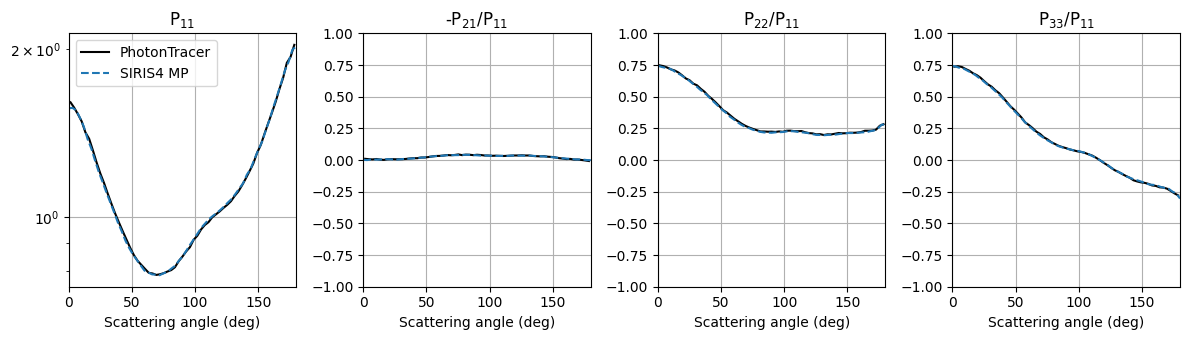

In [27]:
#plot histogram of scattering angles
import matplotlib as mpl
# use tableau colorblind-friendly
colors = mpl.cm.tab10.colors

fig, ax = plt.subplots(1, 4, figsize=(12, 3.5))

ax[0].plot(centers_degrees, p11, label="PhotonTracer", color='black')
ax[1].plot(centers_degrees, -m21, label="PhotonTracer P21/P11", color='black')
ax[2].plot(centers_degrees, m22, label="PhotonTracer P22/P11", color='black')
ax[3].plot(centers_degrees, m33, label="PhotonTracer P23/P11", color='black')
ax[0].plot(angles_siris, p[0,0,:], label="SIRIS4 MP", ls='--')
ax[1].plot(angles_siris, -p[1,0]/p[0,0], label="SIRIS4 MP P21/P11", ls='--')
ax[2].plot(angles_siris, p[1,1]/p[0,0], label="SIRIS4 MP P22/P11", ls='--')
ax[3].plot(angles_siris, p[2,2]/p[0,0], label="SIRIS4 MP P33/P11", ls='--')
ax[0].set_title("P$_{11}$")
ax[0].set_yscale("log")
ax[1].set_title("-P$_{21}$/P$_{11}$")
ax[2].set_title("P$_{22}$/P$_{11}$")
ax[3].set_title("P$_{33}$/P$_{11}$")

ax[0].legend()


#plt.ylabel("-p21/p11")
for i in range(4):
    if i != 0:
        ax[i].set_ylim([-1., 1.])
    ax[i].set_xlabel("Scattering angle (deg)")


    ax[i].grid()
    ax[i].set_xlim([0, 180])

fig.tight_layout()